# 07 Checking the explanations against human rationales

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

Two team members (Annotator A and Annotator B) independently marked the hateful words in up to 100 test comments. In this notebook we:
1. read their sheets and measure how much they agree (Cohen's Kappa),
2. run LIME and SHAP on the same comments,
3. check plausibility: do the explanation words match the human words?
4. check faithfulness: does the model really depend on the words the explanation picks?

Runtime: T4 GPU (about 10 minutes).

## Install LIME

In [13]:
!pip install -q lime

## Mount Google Drive

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports, paths and seed

In [15]:
import os
import re
import sys
import json
import math
import random
from datetime import datetime
from importlib.metadata import version

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from openpyxl import load_workbook
from transformers import AutoTokenizer
from sklearn.metrics import cohen_kappa_score, average_precision_score

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '07_rationale_evaluation.ipynb'
XPLAIN_DIR = os.path.join(BASE, 'data', 'banth_xplain')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
CKPT_DIR = os.path.join(BASE, 'results', 'model_checkpoints')
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
sys.path.append(os.path.join(BASE, 'src'))
from model import load_trained
from explainability.explain import make_predict_fn, lime_word_weights, shap_word_weights

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# The sheet files are named after the annotators; everywhere else we use A and B.
SHEETS = {'Annotator A': 'rationale_sheet_Ifta_Faisal.xlsx', 'Annotator B': 'rationale_sheet_Diab_Alam.xlsx'}
ANNOTATORS = list(SHEETS)
print('Device:', device)

Device: cuda


## Helper functions

Save tables as CSV and LaTeX, and add files to ASSETS.md.

In [16]:
def save_table(df, name, float_format='%.3f'):
    df.to_csv(os.path.join(TAB_DIR, f'{name}.csv'), index=False)
    df.to_latex(os.path.join(TAB_DIR, f'{name}.tex'), index=False, escape=True,
                float_format=float_format, na_rep='--')
    print('Saved:', name, '(.csv and .tex)')

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

## Read the two annotation sheets

For every comment we read the white row under the words. A cell with 1 means the word is marked. We check that the ID in each sheet row matches our sample list, so a moved row would stop the notebook instead of silently mixing up comments.

A comment counts as annotated only if at least one word is marked or "Nothing hateful" is 1. Empty rows mean the annotator didn't get to that comment, so we leave them out. Counting them as "no hateful words" would be wrong.

In [17]:
sample = pd.read_csv(os.path.join(XPLAIN_DIR, 'rationale_sample.csv'), keep_default_na=False)
sample['words'] = sample['words'].map(json.loads)
FIRST_WORD_COL = 5

def is_one(v):
    try:
        return float(v) == 1
    except (TypeError, ValueError):
        return False

def read_sheet(name):
    path = os.path.join(XPLAIN_DIR, SHEETS[name])
    ws = load_workbook(path, data_only=True)['Annotation']
    out, stray = {}, 0
    for _, rec in sample.iterrows():
        k = int(rec['sheet_no'])
        wr, mr = 2 * k, 2 * k + 1
        assert ws.cell(wr, 2).value == rec['comment_id'], f'{name}: row for {rec["comment_id"]} was moved'
        n = len(rec['words'])
        marks = [1 if is_one(ws.cell(mr, FIRST_WORD_COL + j).value) else 0 for j in range(n)]
        stray += sum(is_one(ws.cell(mr, c).value) for c in range(FIRST_WORD_COL + n, FIRST_WORD_COL + 30))
        nothing = is_one(ws.cell(mr, 4).value)
        if sum(marks) > 0 or nothing:
            out[rec['comment_id']] = {'marks': marks, 'nothing_hateful': nothing}
    print(f'{name}: {len(out)} of {len(sample)} comments annotated'
          f" ({sum(v['nothing_hateful'] for v in out.values())} marked nothing hateful); "
          f'{stray} marks outside the words ignored')
    return out

ann = {name: read_sheet(name) for name in ANNOTATORS}
A, B = ANNOTATORS
both = [cid for cid in sample['comment_id'] if cid in ann[A] and cid in ann[B]]
print('Annotated by both:', len(both))

Annotator A: 93 of 100 comments annotated (2 marked nothing hateful); 1 marks outside the words ignored
Annotator B: 57 of 100 comments annotated (2 marked nothing hateful); 0 marks outside the words ignored
Annotated by both: 55


## Agreement between the annotators (T20)

We compare the two annotators word by word on the comments they both did. Every word is a yes/no decision (marked or not).

- Cohen's Kappa: agreement corrected for chance. 0 means no better than chance and 1 means perfect. Values from 0.41 to 0.60 are usually called moderate, and 0.61 to 0.80 substantial (Landis and Koch).
- Raw agreement: share of words where both made the same decision.
- We also report how many words each person marked per comment, to see if one of them marks more than the other.

In [18]:
a_flat = np.concatenate([ann[A][c]['marks'] for c in both])
b_flat = np.concatenate([ann[B][c]['marks'] for c in both])
kappa = cohen_kappa_score(a_flat, b_flat)
raw_agree = float((a_flat == b_flat).mean())
exact_rows = float(np.mean([ann[A][c]['marks'] == ann[B][c]['marks'] for c in both]))

agreement = pd.DataFrame([
    ('Comments annotated by both', str(len(both))),
    ('Words compared', str(len(a_flat))),
    ("Cohen's Kappa (word level)", f'{kappa:.3f}'),
    ('Raw word agreement', f'{raw_agree:.3f}'),
    ('Comments with identical marks', f'{exact_rows:.3f}'),
    (f'Words marked per comment ({A})', f'{a_flat.sum() / len(both):.2f}'),
    (f'Words marked per comment ({B})', f'{b_flat.sum() / len(both):.2f}'),
    (f'Comments annotated ({A})', str(len(ann[A]))),
    (f'Comments annotated ({B})', str(len(ann[B]))),
], columns=['Measure', 'Value'])
display(agreement)
save_table(agreement, 'tab_20_annotator_agreement')
register_asset('T20', 'tables/tab_20_annotator_agreement.csv (+ .tex)',
               "Word-level Cohen's Kappa and raw agreement between the two annotators, with coverage counts",
               NOTEBOOK_NAME, 'III. Dataset (mini rationale set)',
               "TABLE X. Agreement between the two rationale annotators on the comments annotated by both.")

,Measure,Value
0,Comments annotated by both,55
1,Words compared,551
2,Cohen's Kappa (word level),0.559
3,Raw word agreement,0.784
4,Comments with identical marks,0.291
5,Words marked per comment (Annotator A),4.53
6,Words marked per comment (Annotator B),3.93
7,Comments annotated (Annotator A),93
8,Comments annotated (Annotator B),57


Saved: tab_20_annotator_agreement (.csv and .tex)
Registered T20 -> tables/tab_20_annotator_agreement.csv (+ .tex)


## Save the mini rationale dataset

All annotations are saved in one file, data/banth_xplain/banth_xplain_mini.csv: comment ID, text, labels, and each annotator's marks as a list of 0/1 per word (empty if that person didn't annotate the comment). This is the start of our own rationale dataset.

In [19]:
mini = sample[['comment_id', 'clean_text', 'categories']].copy()
mini['words'] = sample['words'].map(lambda w: json.dumps(w, ensure_ascii=False))
for name in ANNOTATORS:
    col = 'rationale_' + name[-1].lower()
    mini[col] = [json.dumps(ann[name][c]['marks']) if c in ann[name] else '' for c in sample['comment_id']]
    mini[col + '_nothing_hateful'] = [int(ann[name][c]['nothing_hateful']) if c in ann[name] else '' for c in sample['comment_id']]
mini.to_csv(os.path.join(XPLAIN_DIR, 'banth_xplain_mini.csv'), index=False, encoding='utf-8')
print('Saved banth_xplain_mini.csv')

Saved banth_xplain_mini.csv


## Load the model

The same trained model as in the explanation notebook, loaded from best_model.pt and model_config.json.

In [20]:
with open(os.path.join(CKPT_DIR, 'model_config.json')) as f:
    cfg = json.load(f)
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = load_trained(cfg['model_name'], os.path.join(CKPT_DIR, cfg['weights_file']), device)
predict_hate = make_predict_fn(model, tokenizer, cfg['max_length'], device)
print('Model loaded')

Model loaded


## Run LIME and SHAP on the annotated comments

We explain every comment that has at least one human-marked word, with the same settings as before (LIME 1,000 samples, SHAP 500 evaluations, seed 42). The scores are saved to a file as we go, so if Colab disconnects, a re-run continues where it stopped.

We also add a Random baseline that gives every word a random score. If LIME or SHAP are not clearly better than Random, their explanations are not useful.

In [21]:
eval_ids = [c for c in sample['comment_id']
            if any(c in ann[n] and sum(ann[n][c]['marks']) > 0 for n in ANNOTATORS)]
text_of = dict(zip(sample['comment_id'], sample['clean_text']))
words_of = dict(zip(sample['comment_id'], sample['words']))

CACHE = os.path.join(REP_DIR, 'explanations_rationale_set.json')
expl = json.load(open(CACHE, encoding='utf-8')) if os.path.exists(CACHE) else {}
for i, cid in enumerate(eval_ids, start=1):
    if cid in expl:
        continue
    _, lw = lime_word_weights(text_of[cid], predict_hate, num_samples=1000, seed=SEED)
    _, sw, _ = shap_word_weights(text_of[cid], predict_hate, max_evals=500, seed=SEED)
    expl[cid] = {'lime': lw.tolist(), 'shap': sw.tolist()}
    if i % 10 == 0 or i == len(eval_ids):
        with open(CACHE, 'w', encoding='utf-8') as f:
            json.dump(expl, f)
        print(f'{i}/{len(eval_ids)} explained')
with open(CACHE, 'w', encoding='utf-8') as f:
    json.dump(expl, f)

rng = np.random.default_rng(SEED)
scores = {cid: {'LIME': np.array(expl[cid]['lime']), 'SHAP': np.array(expl[cid]['shap']),
                'Random': rng.random(len(words_of[cid]))} for cid in eval_ids}
METHODS = ['LIME', 'SHAP', 'Random']

## Plausibility: do the explanations match the human words? (T18)

We use the measures from the HateXplain paper, on the words each annotator marked:
- AUPRC: how well the word scores rank the human-marked words above the others (1 is perfect).
- Token F1: we take as many top-scoring words as the human marked, and compute F1 against the human words.
- IOU F1: the share of comments where the overlap between the top words and the human words, divided by their union, is at least 0.5.

The main reference is Annotator A (the most comments). Annotator B is used as a second reference, to see if the results depend on who annotated.

In [22]:
def top_k(s, k):
    return set(np.argsort(-s, kind='stable')[:k].tolist())

def plausibility(ref):
    ids = [c for c in eval_ids if c in ann[ref] and sum(ann[ref][c]['marks']) > 0]
    rows = []
    for m in METHODS:
        auprc, tok_f1, iou_hit = [], [], []
        for c in ids:
            h = np.array(ann[ref][c]['marks'])
            s = scores[c][m]
            human = set(np.where(h == 1)[0].tolist())
            pred = top_k(s, len(human))
            inter = len(pred & human)
            auprc.append(average_precision_score(h, s) if h.sum() < len(h) else 1.0)
            tok_f1.append(2 * inter / (len(pred) + len(human)))
            iou_hit.append(inter / len(pred | human) >= 0.5)
        rows.append({'Reference': ref, 'Comments': len(ids), 'Method': m, 'AUPRC': np.mean(auprc),
                     'Token F1': np.mean(tok_f1), 'IOU F1': np.mean(iou_hit)})
    return rows

plaus = pd.DataFrame(plausibility(A) + plausibility(B))
display(plaus)
save_table(plaus, 'tab_18_plausibility')
register_asset('T18', 'tables/tab_18_plausibility.csv (+ .tex)',
               'Plausibility of LIME, SHAP and a random baseline against each annotator (AUPRC, token F1, IOU F1)',
               NOTEBOOK_NAME, 'V. Results (plausibility)',
               'TABLE X. Plausibility of word attributions measured against human rationales. Higher is better; Random assigns random scores to words.')

,Reference,Comments,Method,AUPRC,Token F1,IOU F1
0,Annotator A,91,LIME,0.804577,0.682763,0.527473
1,Annotator A,91,SHAP,0.807808,0.714726,0.604396
2,Annotator A,91,Random,0.626838,0.517723,0.351648
3,Annotator B,55,LIME,0.776989,0.658432,0.545455
4,Annotator B,55,SHAP,0.776960,0.690236,0.600000
5,Annotator B,55,Random,0.567341,0.466267,0.327273


Saved: tab_18_plausibility (.csv and .tex)
Registered T18 -> tables/tab_18_plausibility.csv (+ .tex)


## Faithfulness: does the model really use those words? (T19)

A plausible explanation can still be wrong about the model. We test this with the two measures from the ERASER benchmark, on the probability of hate:
- Comprehensiveness: P(hate) of the full comment minus P(hate) after deleting the top words. Higher is better, because if the words really mattered, deleting them should lower the probability.
- Sufficiency: P(hate) of the full comment minus P(hate) when only the top words are kept. Lower is better, because the top words alone should keep the probability up.

We do this with two sizes of top words:
- k = the number of words the human marked, so we can also test the human words themselves (row Human),
- the average over the top 10%, 20%, 30% and 50% of words (AOPC, as in ERASER).

The comments are the ones Annotator A marked, the same as the main plausibility reference.

In [23]:
FRACS = [0.1, 0.2, 0.3, 0.5]
faith_ids = [c for c in eval_ids if c in ann[A] and sum(ann[A][c]['marks']) > 0]

def remove(words, idx):
    return ' '.join(w for i, w in enumerate(words) if i not in idx)

def keep(words, idx):
    return ' '.join(w for i, w in enumerate(words) if i in idx)

full_p = dict(zip(faith_ids, predict_hate([text_of[c] for c in faith_ids])))

def comp_suff(sets):
    # sets: list of (comment_id, set of word positions)
    p_rm = predict_hate([remove(words_of[c], s) for c, s in sets])
    p_kp = predict_hate([keep(words_of[c], s) for c, s in sets])
    p0 = np.array([full_p[c] for c, _ in sets])
    return p0 - p_rm, p0 - p_kp

human_sets = [(c, set(np.where(np.array(ann[A][c]['marks']) == 1)[0].tolist())) for c in faith_ids]
rows = []
comp, suff = comp_suff(human_sets)
rows.append({'Method': 'Human', 'Comp. (k = human)': comp.mean(), 'Suff. (k = human)': suff.mean(),
             'Comp. (AOPC)': np.nan, 'Suff. (AOPC)': np.nan})
for m in METHODS:
    comp_h, suff_h = comp_suff([(c, top_k(scores[c][m], len(s))) for c, s in human_sets])
    comp_bins, suff_bins = [], []
    for f in FRACS:
        cs, ss = comp_suff([(c, top_k(scores[c][m], max(1, math.ceil(f * len(words_of[c]))))) for c in faith_ids])
        comp_bins.append(cs.mean())
        suff_bins.append(ss.mean())
    rows.append({'Method': m, 'Comp. (k = human)': comp_h.mean(), 'Suff. (k = human)': suff_h.mean(),
                 'Comp. (AOPC)': np.mean(comp_bins), 'Suff. (AOPC)': np.mean(suff_bins)})
faith = pd.DataFrame(rows)
faith.insert(1, 'Comments', len(faith_ids))
display(faith)
print(f'Mean P(hate) of the full comments: {np.mean(list(full_p.values())):.3f}')
save_table(faith, 'tab_19_faithfulness')
register_asset('T19', 'tables/tab_19_faithfulness.csv (+ .tex)',
               'Comprehensiveness and sufficiency of human, LIME, SHAP and random rationales (k = human length and AOPC)',
               NOTEBOOK_NAME, 'V. Results (faithfulness)',
               'TABLE X. Faithfulness of rationales on the annotated test comments. Higher comprehensiveness and lower sufficiency are better.')

,Method,Comments,Comp. (k = human),Suff. (k = human),Comp. (AOPC),Suff. (AOPC)
0,Human,91,0.409491,-0.022697,NaN,NaN
1,LIME,91,0.471276,-0.125842,0.412271,-0.117204
2,SHAP,91,0.482273,-0.133030,0.423130,-0.131072
3,Random,91,0.156806,0.176091,0.083785,0.266343


Mean P(hate) of the full comments: 0.620
Saved: tab_19_faithfulness (.csv and .tex)
Registered T19 -> tables/tab_19_faithfulness.csv (+ .tex)


## Human vs model highlights (F08)

For 3 comments annotated by both people (picked randomly with seed 42), we show the words marked by each annotator and the top words from LIME and SHAP. Each explanation shows as many words as Annotator A marked, so the rows are comparable. Marked words are red. Emoji can't be drawn, so they are left out of the picture.

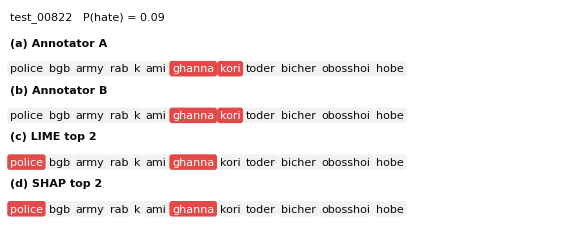

Registered F08.1 -> figures/fig_08_human_vs_model_test_00822.png


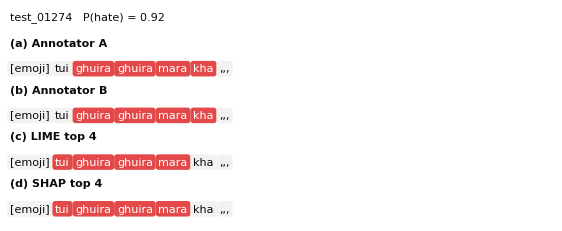

Registered F08.2 -> figures/fig_08_human_vs_model_test_01274.png


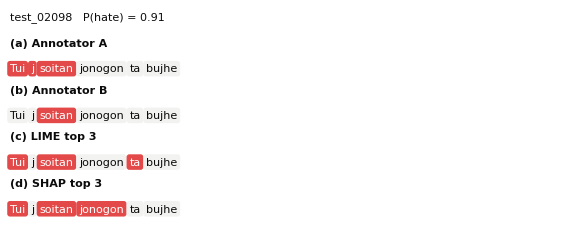

Registered F08.3 -> figures/fig_08_human_vs_model_test_02098.png


In [24]:
RED, INK, MUTED = '#e34948', '#0b0b0b', '#52514e'
plt.rcParams.update({'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white'})

def display_word(w):
    s = w.encode('ascii', 'ignore').decode()
    return s if s else '[emoji]'

def mark_row(ax, words, marked, label):
    ax.axis('off')
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    line_h = (8 * 2.3 * fig.dpi / 72) / ax.bbox.height
    gap = (4 * fig.dpi / 72) / ax.bbox.width
    ax.text(0, 1, label, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color=INK)
    x, y = 0.0, 1 - line_h
    for i, w in enumerate(words):
        box = dict(boxstyle='round,pad=0.25', edgecolor='none',
                   facecolor=RED if i in marked else '#f2f2f0')
        t = ax.text(x, y, display_word(w), transform=ax.transAxes, fontsize=8, va='top',
                    color='white' if i in marked else INK, bbox=box)
        width = t.get_window_extent(renderer=renderer).width / ax.bbox.width
        if x > 0 and x + width > 1:
            x, y = 0.0, y - line_h
            t.set_position((x, y))
        x += width + gap

both_marked = [c for c in both if c in scores and sum(ann[A][c]['marks']) > 0 and sum(ann[B][c]['marks']) > 0]
fig_ids = pd.Series(both_marked).sample(min(3, len(both_marked)), random_state=SEED).tolist()
for k, cid in enumerate(fig_ids, start=1):
    words = words_of[cid]
    n_h = int(sum(ann[A][cid]['marks']))
    rows_ = [(f'(a) {A}', set(np.where(np.array(ann[A][cid]['marks']) == 1)[0])),
             (f'(b) {B}', set(np.where(np.array(ann[B][cid]['marks']) == 1)[0])),
             (f'(c) LIME top {n_h}', top_k(scores[cid]['LIME'], n_h)),
             (f'(d) SHAP top {n_h}', top_k(scores[cid]['SHAP'], n_h))]
    lines = int(np.ceil(sum(len(display_word(w)) + 2 for w in words) / 90))
    panel_h = 0.3 + 0.3 * lines
    fig = plt.figure(figsize=(7.0, 0.35 + 4 * panel_h))
    gs = fig.add_gridspec(5, 1, height_ratios=[0.35] + [panel_h] * 4, hspace=0.1)
    head = fig.add_subplot(gs[0]); head.axis('off')
    head.text(0, 0.9, f'{cid}   P(hate) = {full_p.get(cid, predict_hate([text_of[cid]])[0]):.2f}',
              fontsize=8, color=INK, va='top', transform=head.transAxes)
    for r, (label, marked) in enumerate(rows_, start=1):
        mark_row(fig.add_subplot(gs[r]), words, marked, label)
    name = f'fig_08_human_vs_model_{cid}.png'
    fig.savefig(os.path.join(FIG_DIR, name))
    plt.show()
    register_asset(f'F08.{k}', f'figures/{name}',
                   f'Human rationales from both annotators vs LIME and SHAP top words for {cid}',
                   NOTEBOOK_NAME, 'V. Results (plausibility)',
                   f'Fig. X. Words marked by the two annotators (a, b) and the top words selected by LIME (c) and SHAP (d) for test comment {cid}.')

## Save all numbers (M11)

Kappa, plausibility, faithfulness, the comment counts used for each, and the settings go into metrics_rationale.json.

In [25]:
metrics = {
    'step': 'rationale_check', 'notebook': NOTEBOOK_NAME,
    'date': datetime.now().isoformat(timespec='seconds'), 'seed': SEED,
    'annotators': ANNOTATORS,
    'sample_size': len(sample),
    'annotated': {n: len(ann[n]) for n in ANNOTATORS},
    'nothing_hateful': {n: int(sum(v['nothing_hateful'] for v in ann[n].values())) for n in ANNOTATORS},
    'annotated_by_both': len(both),
    'words_compared': int(len(a_flat)),
    'cohen_kappa_word_level': float(kappa),
    'raw_word_agreement': raw_agree,
    'comments_with_identical_marks': exact_rows,
    'plausibility': plaus.to_dict(orient='records'),
    'faithfulness': faith.to_dict(orient='records'),
    'faithfulness_comments': len(faith_ids),
    'mean_p_hate_full': float(np.mean(list(full_p.values()))),
    'settings': {'lime_samples': 1000, 'shap_max_evals': 500, 'aopc_fractions': FRACS,
                 'lime_version': version('lime'), 'shap_version': version('shap'),
                 'explained_output': 'binary head, probability of hate',
                 'unannotated_rows': 'excluded (not treated as no rationale)'},
    'figure_comments': fig_ids,
}
path = os.path.join(REP_DIR, 'metrics_rationale.json')
with open(path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
print('Saved:', path)
register_asset('M11', 'evaluation_reports/metrics_rationale.json (+ explanations_rationale_set.json, data/banth_xplain/banth_xplain_mini.csv)',
               'Kappa, plausibility and faithfulness results with counts and settings; word scores; the mini rationale dataset',
               NOTEBOOK_NAME, 'III. Dataset / V. Results',
               'Not a figure; source for every rationale-evaluation number quoted in the text.')

Saved: /content/drive/MyDrive/ML_Project/results/evaluation_reports/metrics_rationale.json
Registered M11 -> evaluation_reports/metrics_rationale.json (+ explanations_rationale_set.json, data/banth_xplain/banth_xplain_mini.csv)


## Summary

We read the two annotation sheets, measured agreement (T20), saved the mini rationale dataset (banth_xplain_mini.csv), and compared LIME, SHAP and a random baseline with the human words, both for plausibility (T18) and faithfulness (T19), plus 3 side-by-side figures (F08). Comments that were not annotated were left out and not counted as empty.

Next is the demo app and the report.

## Remember this

- What we did: compared LIME and SHAP explanations with words that two people marked by hand, and tested whether the model really depends on those words.
- Why: an explanation can look sensible and still not show what the model actually used, so both checks are needed.
- Key number: annotator agreement Kappa 0.559 (moderate); SHAP matches the human words with token F1 0.715 vs 0.518 for random, and deleting its top words lowers P(hate) by 0.48 vs 0.16 for random.